# Visit with Us — Wellness Tourism Package Prediction
## An End-to-End MLOps Pipeline

---

## 1. Problem Definition

### Business Context

**"Visit with Us"** is a travel company that is introducing a new **Wellness Tourism Package**.
Today, the company identifies potential buyers manually. That approach is inconsistent,
slow, and error-prone, which leads to wasted marketing spend and missed opportunities.

Wellness tourism is travel that allows a traveller to maintain, enhance, or begin a
healthier lifestyle. It is one of the fastest-growing segments in travel, so getting
targeting right has a direct revenue impact.

### Objective

Build and deploy an **automated MLOps pipeline** that predicts whether a customer will
purchase the Wellness Tourism Package **before the sales team contacts them**.

The pipeline must cover the full lifecycle:

| Stage | What it does | Where it runs |
|---|---|---|
| 1. Data Registration | Register the raw dataset as a versioned source of truth | Hugging Face Dataset Space |
| 2. Data Preparation | Clean, split, and publish train/test sets | GitHub Actions → HF |
| 3. Model Building | Tune, track experiments, evaluate, register the model | MLflow + HF Model Hub |
| 4. Deployment | Serve predictions through a web app | Docker → HF Space (Streamlit) |
| 5. CI/CD | Re-run everything automatically on each code update | GitHub Actions |

### Why this matters

A customer contacted at random converts at roughly the base rate (~19%). If the model
can rank customers by purchase probability, the same sales effort can be concentrated on
a much richer subset — lifting conversion per call and cutting wasted outreach.

### Success criteria

Because only about 19% of customers actually buy, **accuracy alone is misleading** — a
model that predicts "nobody buys" would still score ~81%. We therefore optimise and
judge the model on **F1**, with **recall** watched closely (a missed buyer is lost
revenue) and **ROC-AUC** used to measure overall ranking quality.

## 2. Import Libraries

In [1]:
# Data handling
import warnings
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)
import xgboost as xgb

# Display / warning configuration
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
%matplotlib inline

print("Libraries imported successfully.")
print("XGBoost version:", xgb.__version__)

Libraries imported successfully.
XGBoost version: 3.4.1


## 3. Data Loading

In the deployed pipeline this data is pulled directly from the **Hugging Face dataset
space** rather than from a local file, so every stage reads from one versioned source:

```python
from huggingface_hub import hf_hub_download

path = hf_hub_download(
    repo_id=f"{HF_USERNAME}/tourism-wellness-dataset",
    filename="tourism.csv",
    repo_type="dataset",
    token=os.getenv("HF_TOKEN"),
)
df = pd.read_csv(path, index_col=0)
```

For this notebook we read the same file locally so the analysis is reproducible without
credentials.

In [2]:
# index_col=0 drops the unnamed index column carried over in the CSV export
df = pd.read_csv("tourism.csv", index_col=0)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded: 4128 rows x 20 columns


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


## 4. Data Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 4128 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4128 non-null   int64  
 1   ProdTaken                 4128 non-null   int64  
 2   Age                       4128 non-null   float64
 3   TypeofContact             4128 non-null   str    
 4   CityTier                  4128 non-null   int64  
 5   DurationOfPitch           4128 non-null   float64
 6   Occupation                4128 non-null   str    
 7   Gender                    4128 non-null   str    
 8   NumberOfPersonVisiting    4128 non-null   int64  
 9   NumberOfFollowups         4128 non-null   float64
 10  ProductPitched            4128 non-null   str    
 11  PreferredPropertyStar     4128 non-null   float64
 12  MaritalStatus             4128 non-null   str    
 13  NumberOfTrips             4128 non-null   float64
 14  Passport                

In [4]:
# Statistical summary of numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4128.0,202527.763808,1409.439133,200000.0,201320.75,202603.5,203748.25,204887.0
ProdTaken,4128.0,0.193072,0.394757,0.0,0.00,0.0,0.00,1.0
Age,4128.0,37.231831,9.174521,18.0,31.00,36.0,43.00,61.0
CityTier,4128.0,1.663275,0.920640,1.0,1.00,1.0,3.00,3.0
DurationOfPitch,4128.0,15.584787,8.398142,5.0,9.00,14.0,20.00,127.0
NumberOfPersonVisiting,4128.0,2.949370,0.718818,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4128.0,3.741521,1.006786,1.0,3.00,4.0,4.00,6.0
PreferredPropertyStar,4128.0,3.578488,0.795031,3.0,3.00,3.0,4.00,5.0
NumberOfTrips,4128.0,3.295300,1.856300,1.0,2.00,3.0,4.00,22.0
Passport,4128.0,0.295300,0.456233,0.0,0.00,0.0,1.00,1.0


In [5]:
# Statistical summary of categorical features
df.describe(include="object").T

,count,unique,top,freq
TypeofContact,4128,2,Self Enquiry,2918
Occupation,4128,4,Salaried,1999
Gender,4128,3,Male,2463
ProductPitched,4128,5,Basic,1615
MaritalStatus,4128,4,Married,1990
Designation,4128,5,Executive,1615


In [6]:
# Missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "  None")

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Unique CustomerIDs: {df['CustomerID'].nunique()} (rows: {len(df)})")

Missing values per column:
  None

Duplicate rows: 0
Unique CustomerIDs: 4128 (rows: 4128)


In [7]:
# Target variable balance
target_counts = df["ProdTaken"].value_counts()
target_pct = df["ProdTaken"].value_counts(normalize=True) * 100

print("Target variable (ProdTaken) distribution:")
for cls in [0, 1]:
    label = "Purchased" if cls == 1 else "Did not purchase"
    print(f"  {cls} ({label}): {target_counts[cls]:>4} ({target_pct[cls]:.2f}%)")

print(f"\nImbalance ratio: {target_counts[0] / target_counts[1]:.2f} : 1")

Target variable (ProdTaken) distribution:
  0 (Did not purchase): 3331 (80.69%)
  1 (Purchased):  797 (19.31%)

Imbalance ratio: 4.18 : 1


### Observations — Data Overview

- The dataset has **4,128 rows and 20 columns**, with **no missing values** and **no
  duplicate rows**, so it is unusually clean for a customer dataset.
- **`CustomerID` has 4,128 unique values — one per row.** It is a pure identifier with no
  predictive signal, so it must be dropped before modelling; leaving it in would let the
  model memorise individual customers rather than learn patterns.
- The target **`ProdTaken` is imbalanced**: only **19.31%** of customers purchased, a
  ratio of roughly **4.18 : 1**. This drives three decisions later: stratified splitting,
  `scale_pos_weight` in XGBoost, and F1 rather than accuracy as the tuning metric.
- Several numeric columns show suspicious extremes worth checking in the univariate
  analysis: `NumberOfTrips` reaches 22, `DurationOfPitch` reaches 127, and
  `MonthlyIncome` spans 1,000 to 98,678.

## 5. Exploratory Data Analysis

### 5.1 Univariate Analysis — Target Variable

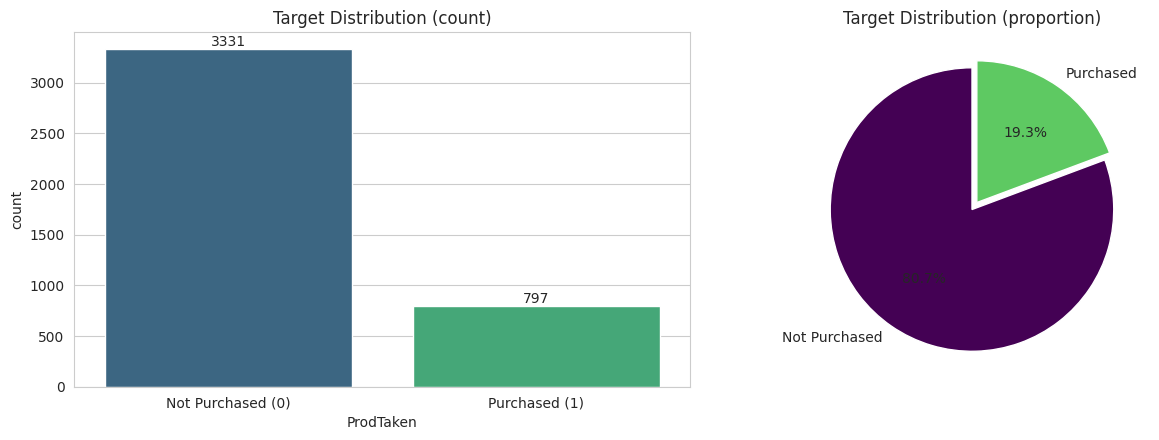

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(x="ProdTaken", data=df, ax=axes[0], palette="viridis", hue="ProdTaken", legend=False)
axes[0].set_title("Target Distribution (count)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Not Purchased (0)", "Purchased (1)"])
for container in axes[0].containers:
    axes[0].bar_label(container)

axes[1].pie(
    target_counts, labels=["Not Purchased", "Purchased"],
    autopct="%1.1f%%", startangle=90, colors=["#440154", "#5ec962"], explode=(0, 0.06)
)
axes[1].set_title("Target Distribution (proportion)")

plt.tight_layout()
plt.show()

### 5.2 Univariate Analysis — Numerical Features

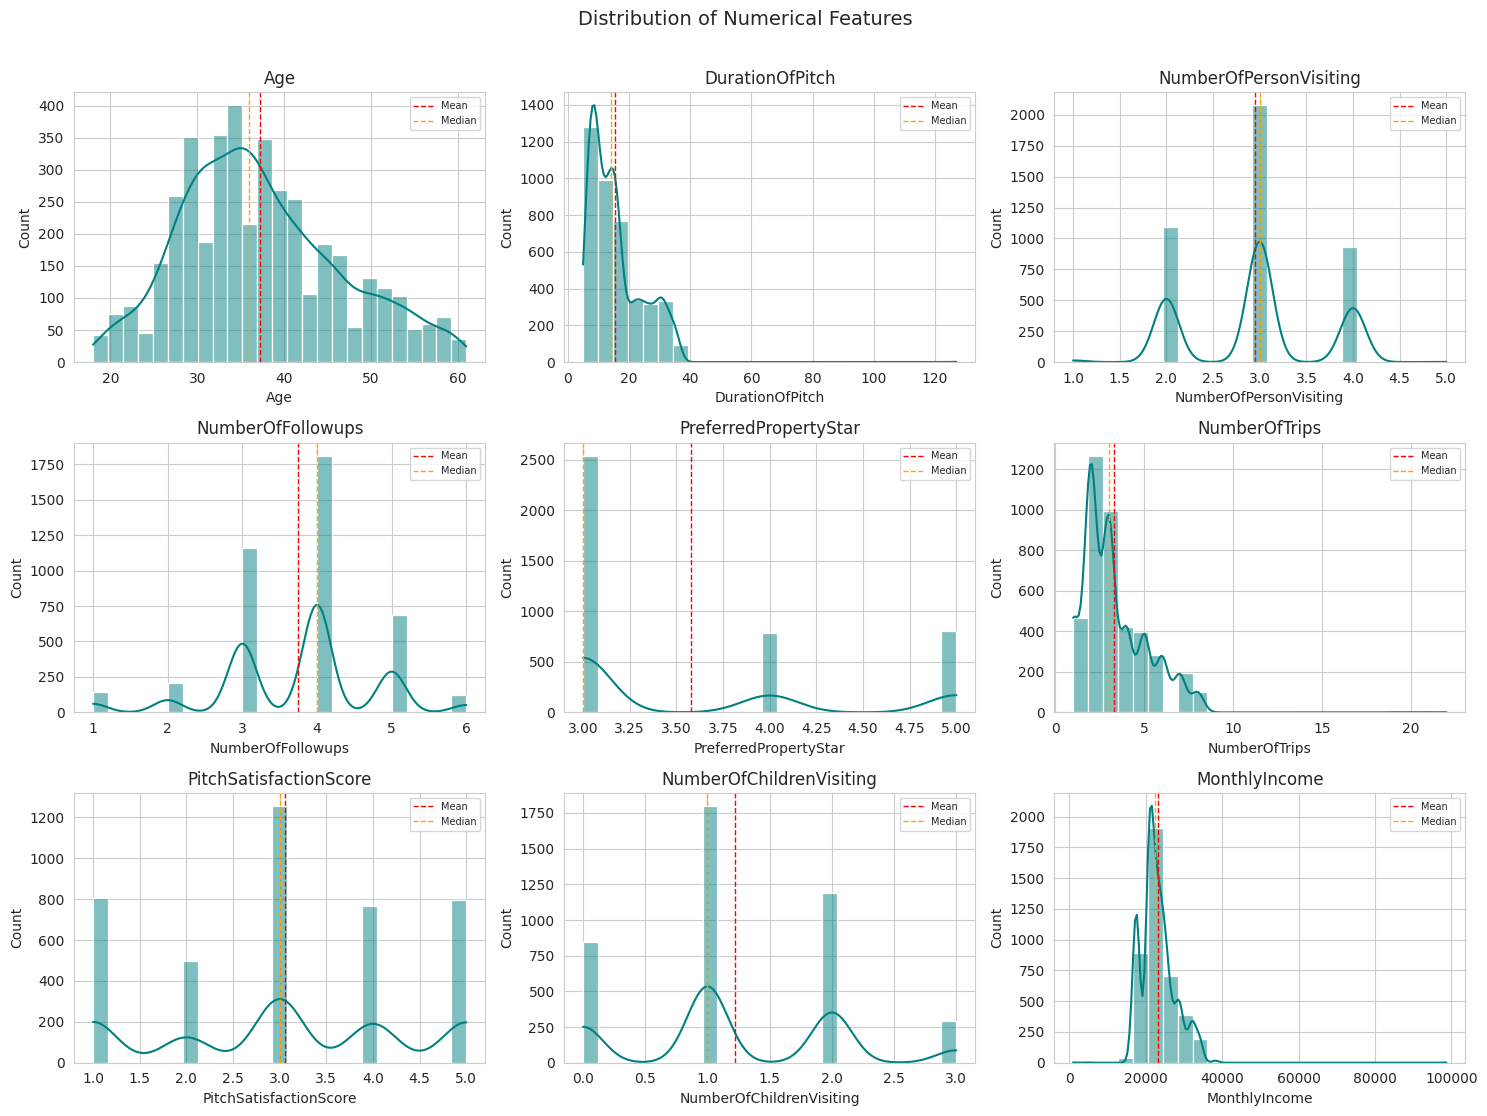

In [9]:
numeric_features = [
    "Age", "DurationOfPitch", "NumberOfPersonVisiting", "NumberOfFollowups",
    "PreferredPropertyStar", "NumberOfTrips", "PitchSatisfactionScore",
    "NumberOfChildrenVisiting", "MonthlyIncome",
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), numeric_features):
    sns.histplot(df[col], kde=True, ax=ax, color="teal", bins=25)
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1, label="Mean")
    ax.axvline(df[col].median(), color="orange", linestyle="--", linewidth=1, label="Median")
    ax.set_title(col)
    ax.legend(fontsize=7)

plt.suptitle("Distribution of Numerical Features", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

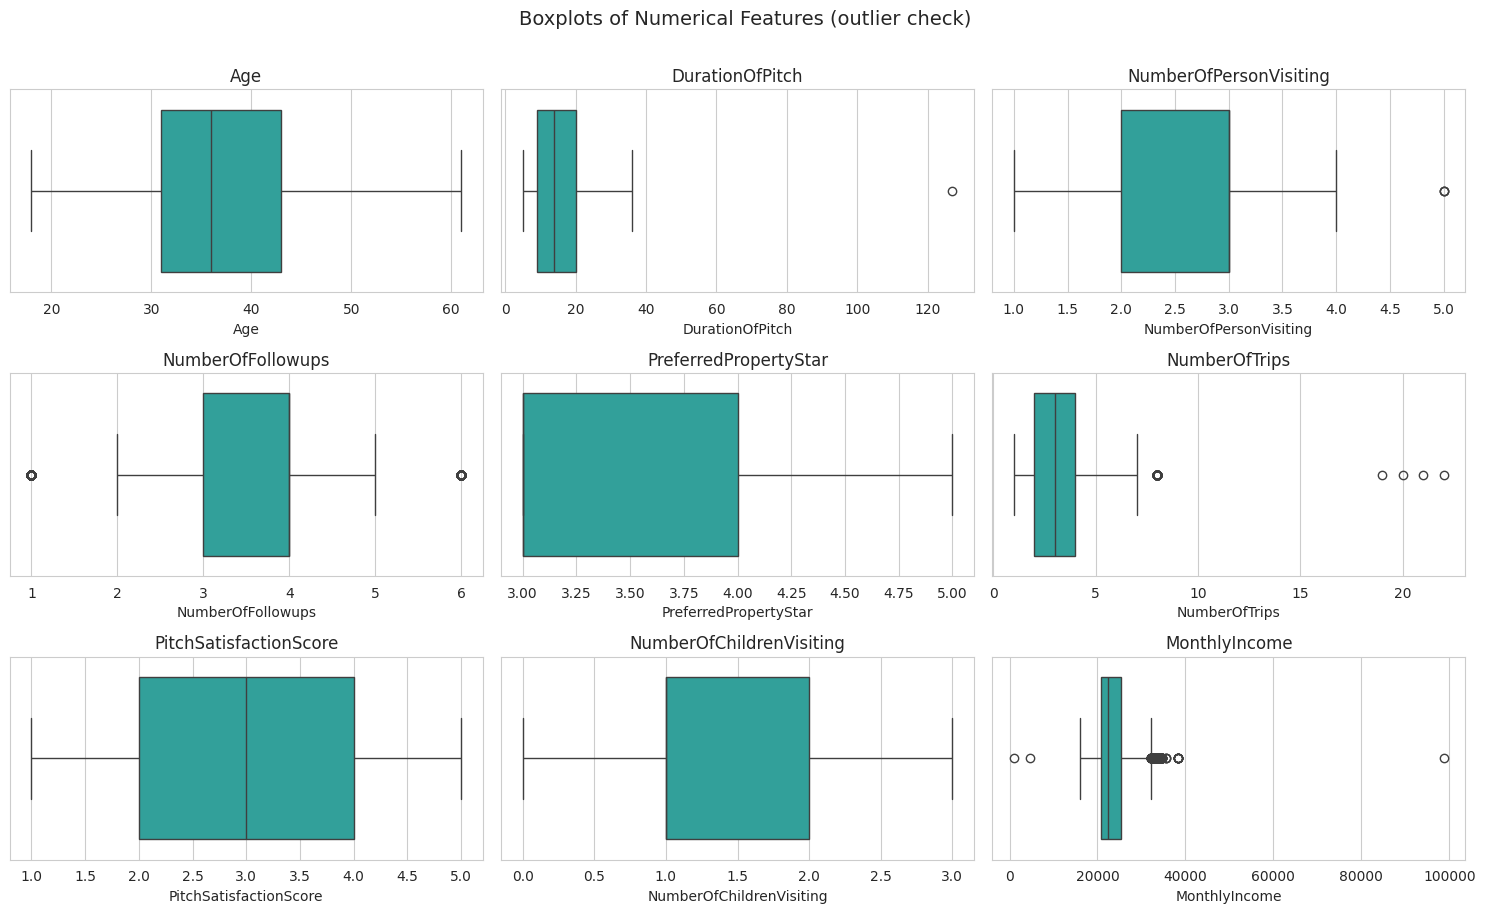

In [10]:
# Boxplots reveal outliers more clearly than histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), numeric_features):
    sns.boxplot(x=df[col], ax=ax, color="lightseagreen")
    ax.set_title(col)

plt.suptitle("Boxplots of Numerical Features (outlier check)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Quantify the suspicious values flagged in the overview
print("NumberOfTrips value counts (note the gap between 8 and 19):")
print(df["NumberOfTrips"].value_counts().sort_index())

print(f"\nDurationOfPitch above 60 minutes: {(df['DurationOfPitch'] > 60).sum()} rows")
print(f"MonthlyIncome below 5,000: {(df['MonthlyIncome'] < 5000).sum()} rows")
print(f"MonthlyIncome above 50,000: {(df['MonthlyIncome'] > 50000).sum()} rows")

NumberOfTrips value counts (note the gap between 8 and 19):
NumberOfTrips
1.0      467
2.0     1267
3.0      993
4.0      422
5.0      396
6.0      283
7.0      193
8.0      103
19.0       1
20.0       1
21.0       1
22.0       1
Name: count, dtype: int64

DurationOfPitch above 60 minutes: 1 rows
MonthlyIncome below 5,000: 2 rows
MonthlyIncome above 50,000: 1 rows


### Observations — Numerical Features

- **`Age`** is roughly normal, centred near 37 and spanning 18–61 — a broad working-age
  customer base with no anomalies.
- **`MonthlyIncome`** is tightly clustered around ~23,000 but has a long right tail plus a
  handful of extreme values at both ends (2 rows below 5,000, 2 above 50,000). These look
  like data-entry errors rather than genuine customers.
- **`NumberOfTrips`** shows a **clear discontinuity**: values run 1–8, then jump straight
  to 19–22 with nothing in between. That gap is the signature of a data-entry problem, not
  a real segment of hyper-frequent travellers.
- **`DurationOfPitch`** is right-skewed with a maximum of 127 minutes against a median of
  14 — a two-hour sales pitch is implausible and almost certainly an error.
- **`NumberOfFollowups`, `PreferredPropertyStar`, `PitchSatisfactionScore`,
  `NumberOfPersonVisiting`, `NumberOfChildrenVisiting`** are all discrete, low-cardinality
  variables behaving like ordinal categories rather than continuous measures.

**Modelling decision:** we keep these outliers rather than removing or capping them.
XGBoost is tree-based, so it splits on thresholds and is inherently robust to extreme
values — unlike a linear model, it will not be distorted by them. Dropping those rows
would discard real customers, and capping would require an arbitrary threshold. We simply
note them as a **data-quality issue to raise with the source system**.

### 5.3 Univariate Analysis — Categorical Features

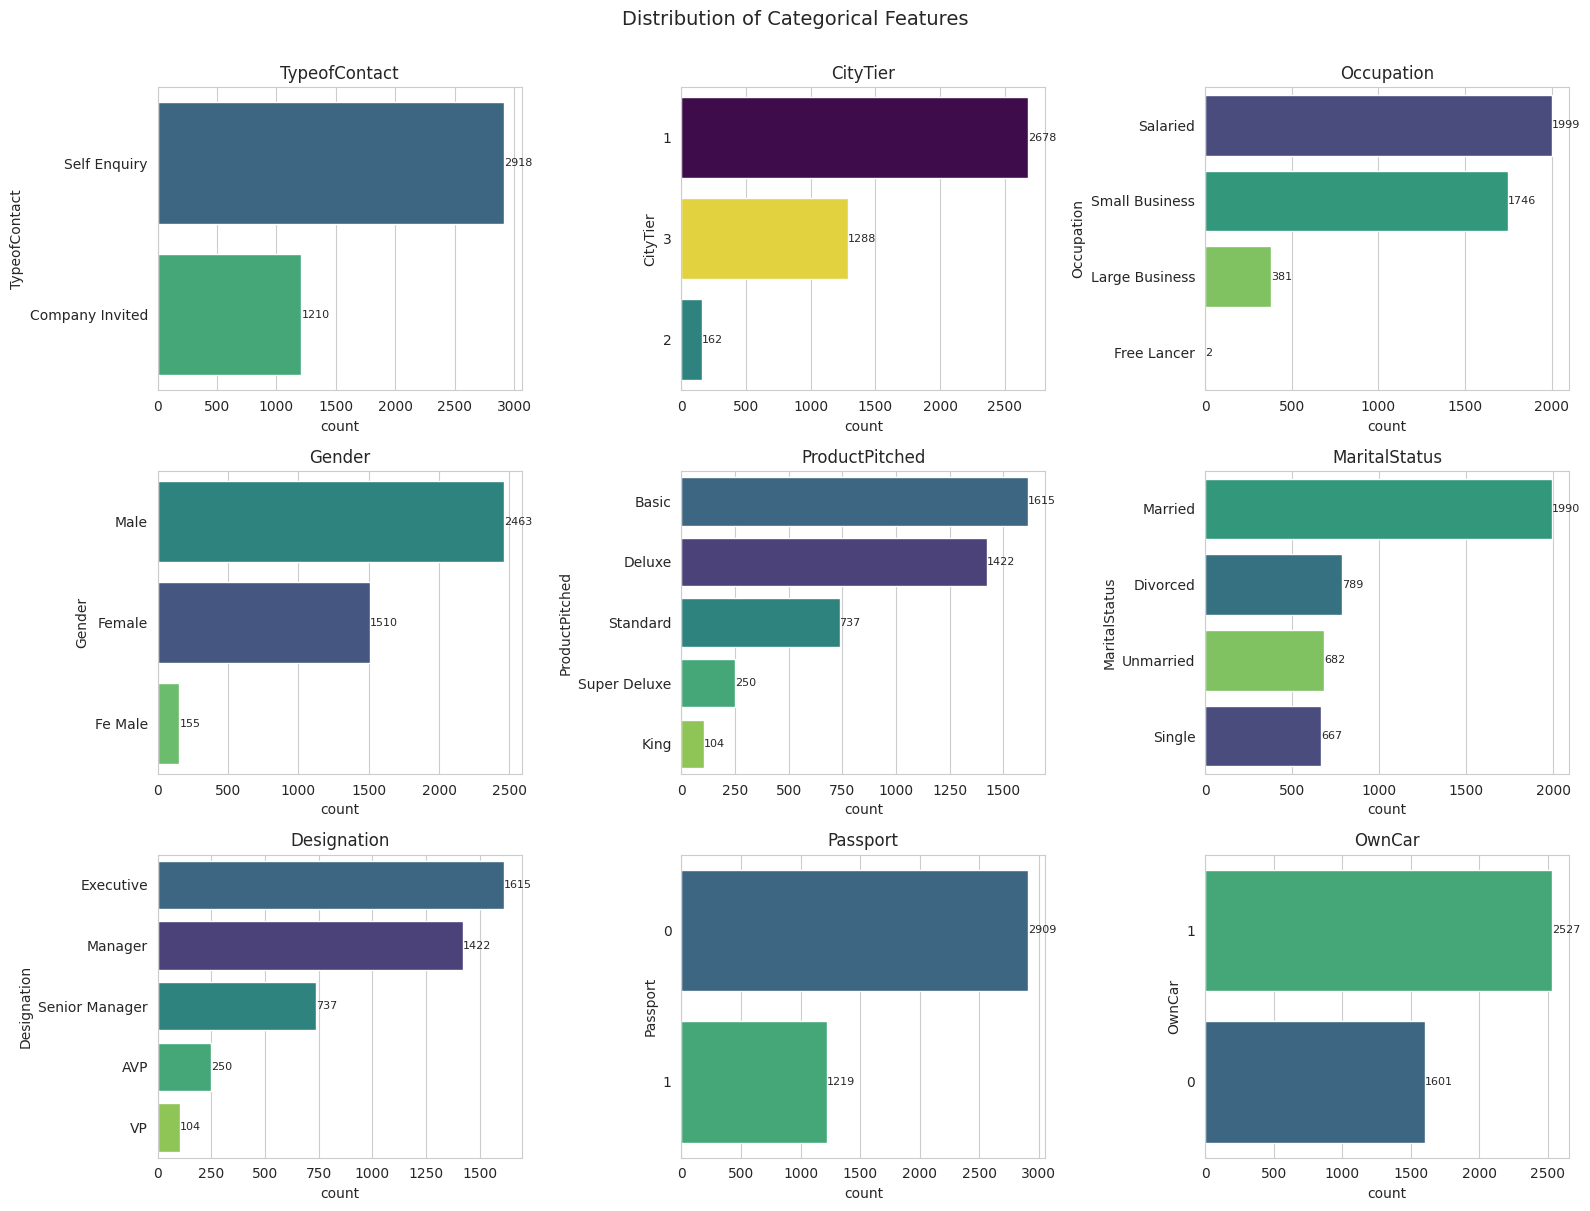

In [12]:
categorical_features = [
    "TypeofContact", "CityTier", "Occupation", "Gender",
    "ProductPitched", "MaritalStatus", "Designation", "Passport", "OwnCar",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), categorical_features):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, ax=ax, palette="viridis", order=order,
                  hue=col, legend=False)
    ax.set_title(col)
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

plt.suptitle("Distribution of Categorical Features", y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Inspect the category levels for data-quality problems
for col in ["Gender", "Occupation", "MaritalStatus", "Designation", "ProductPitched"]:
    print(f"{col}:")
    print(df[col].value_counts().to_string())
    print()

Gender:
Gender
Male       2463
Female     1510
Fe Male     155

Occupation:
Occupation
Salaried          1999
Small Business    1746
Large Business     381
Free Lancer          2

MaritalStatus:
MaritalStatus
Married      1990
Divorced      789
Unmarried     682
Single        667

Designation:
Designation
Executive         1615
Manager           1422
Senior Manager     737
AVP                250
VP                 104

ProductPitched:
ProductPitched
Basic           1615
Deluxe          1422
Standard         737
Super Deluxe     250
King             104



### Observations — Categorical Features

Two genuine **data-quality problems** surface here:

1. **`Gender` contains three levels, not two:** `Male` (2,463), `Female` (1,510), and
   **`Fe Male` (155)**. `Fe Male` is plainly a data-entry variant of `Female`. If left
   alone, one-hot encoding would create a meaningless third gender category and split
   155 female customers away from the rest. **This must be merged.**

2. **`Occupation` has an extremely rare level:** `Free Lancer` appears only **2 times**
   out of 4,128 rows (0.05%). With so few observations the model cannot learn anything
   reliable about freelancers, and the category may be missing entirely from some
   cross-validation folds. We handle this by declaring the category vocabulary explicitly
   to the encoder so the column stays stable across folds.

Other observations:

- **`MaritalStatus`** contains both `Single` (667) and `Unmarried` (682) — semantically
  overlapping labels. We **keep them separate**: merging assumes they mean the same thing,
  and a tree model can learn their effects independently if they differ. This is flagged
  as a definition question for the business.
- **`Designation`** is heavily skewed toward `Executive` (1,615) and `Manager` (1,422),
  tapering through `Senior Manager` (737) and `AVP` (250) to only 104 `VP`s — mirroring a
  normal corporate pyramid.
- **`CityTier`** is dominated by Tier 1 (2,678), followed by Tier 3 (1,288), with **Tier 2
  very sparse at just 162 customers**. That small Tier 2 sample is worth remembering when
  we look at conversion rates by tier later — rates computed on 162 customers carry much
  wider uncertainty than those computed on 2,678.
- **`Passport`**: only **29.53%** of customers hold one — a meaningful constraint for any
  international wellness package.

### 5.4 Bivariate Analysis — Features vs Target

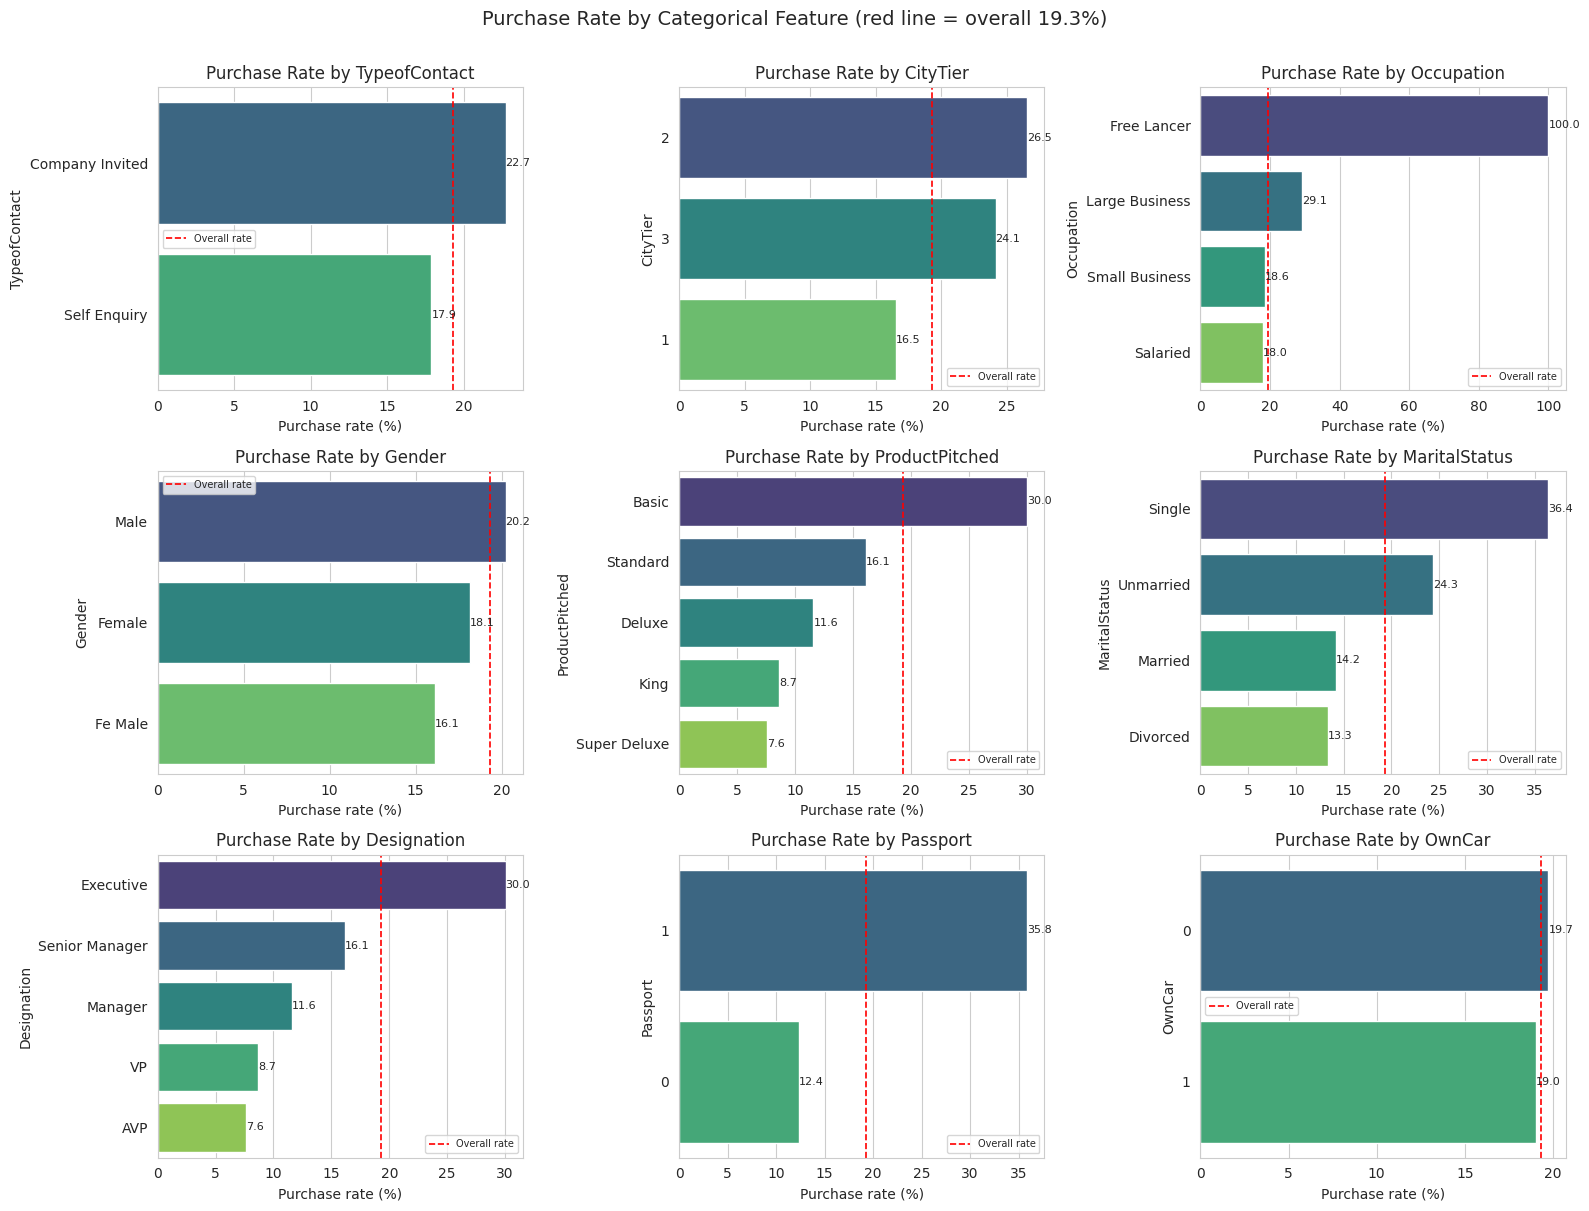

In [14]:
# Conversion rate by categorical feature: the key business view
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), categorical_features):
    rates = df.groupby(col)["ProdTaken"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rates.values, y=rates.index.astype(str), ax=ax,
                palette="viridis", hue=rates.index.astype(str), legend=False)
    ax.axvline(df["ProdTaken"].mean() * 100, color="red", linestyle="--",
               linewidth=1.2, label="Overall rate")
    ax.set_title(f"Purchase Rate by {col}")
    ax.set_xlabel("Purchase rate (%)")
    ax.legend(fontsize=7)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", fontsize=8)

plt.suptitle("Purchase Rate by Categorical Feature (red line = overall 19.3%)",
             y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

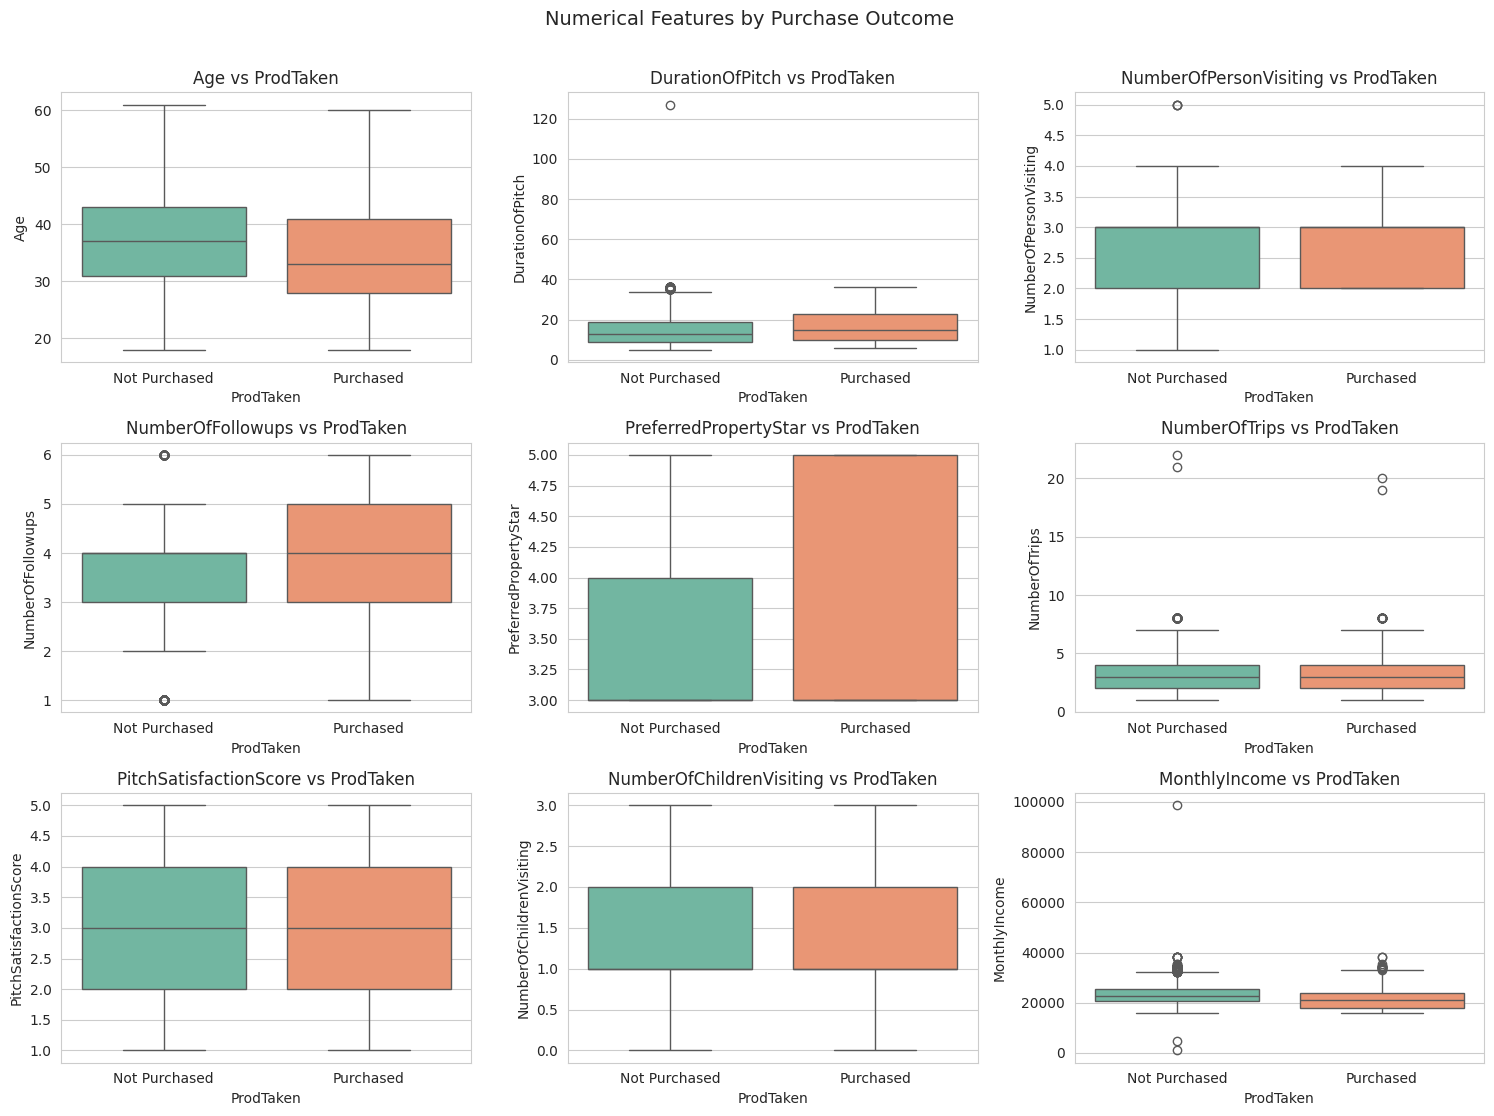

In [15]:
# Numerical features split by purchase outcome
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), numeric_features):
    sns.boxplot(x="ProdTaken", y=col, data=df, ax=ax, palette="Set2",
                hue="ProdTaken", legend=False)
    ax.set_title(f"{col} vs ProdTaken")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not Purchased", "Purchased"])

plt.suptitle("Numerical Features by Purchase Outcome", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Quantify the strongest categorical signals
print("PURCHASE RATE BY KEY SEGMENTS")
print("=" * 55)
print(f"Overall baseline purchase rate: {df['ProdTaken'].mean():.2%}\n")

for col in ["Passport", "CityTier", "Designation", "ProductPitched",
            "MaritalStatus", "TypeofContact"]:
    summary = df.groupby(col).agg(
        customers=("ProdTaken", "size"),
        purchase_rate=("ProdTaken", "mean"),
    )
    summary["purchase_rate"] = (summary["purchase_rate"] * 100).round(2)
    summary = summary.sort_values("purchase_rate", ascending=False)
    print(f"--- {col} ---")
    print(summary.to_string())
    print()

PURCHASE RATE BY KEY SEGMENTS
Overall baseline purchase rate: 19.31%

--- Passport ---
          customers  purchase_rate
Passport                          
1              1219          35.85
0              2909          12.38

--- CityTier ---
          customers  purchase_rate
CityTier                          
2               162          26.54
3              1288          24.15
1              2678          16.54

--- Designation ---
                customers  purchase_rate
Designation                             
Executive            1615          30.03
Senior Manager        737          16.15
Manager              1422          11.60
VP                    104           8.65
AVP                   250           7.60

--- ProductPitched ---
                customers  purchase_rate
ProductPitched                          
Basic                1615          30.03
Standard              737          16.15
Deluxe               1422          11.60
King                  104           8.65
Su

In [17]:
# Mean of each numerical feature by outcome, with the relative gap
comparison = df.groupby("ProdTaken")[numeric_features].mean().T
comparison.columns = ["Not Purchased", "Purchased"]
comparison["Difference"] = comparison["Purchased"] - comparison["Not Purchased"]
comparison["% Difference"] = (
    comparison["Difference"] / comparison["Not Purchased"] * 100
).round(2)
comparison.round(3)

,Not Purchased,Purchased,Difference,% Difference
Age,37.927,34.326,-3.601,-9.49
DurationOfPitch,15.247,16.996,1.749,11.47
NumberOfPersonVisiting,2.948,2.955,0.007,0.23
NumberOfFollowups,3.687,3.970,0.283,7.68
PreferredPropertyStar,3.539,3.742,0.202,5.71
NumberOfTrips,3.281,3.354,0.073,2.21
PitchSatisfactionScore,3.026,3.206,0.180,5.94
NumberOfChildrenVisiting,1.220,1.238,0.018,1.50
MonthlyIncome,23472.895,21947.915,-1524.980,-6.50


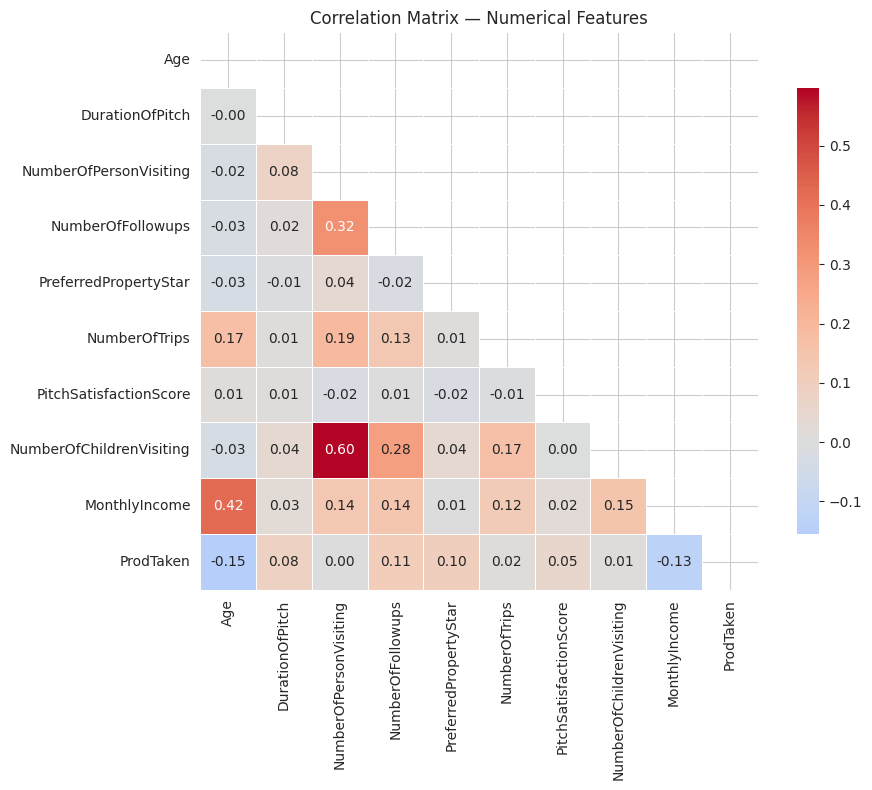

In [18]:
# Correlation among numerical features (multicollinearity check)
plt.figure(figsize=(10, 8))
corr = df[numeric_features + ["ProdTaken"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()

### Observations — Bivariate Analysis

**The strongest single predictor is `Passport`:**
- Customers **with** a passport purchase at **35.85%**
- Customers **without** one purchase at **12.38%**
- That is a **2.9x difference** — the largest gap of any feature in the dataset. It makes
  intuitive sense: a passport signals both intent and ability to travel internationally.

**`CityTier` — the pattern is not a clean gradient:**
- Tier 2: **26.54%** | Tier 3: **24.15%** | Tier 1: **16.54%**
- **Tier 2 converts best**, not Tier 3 as a simple "less developed = more eager" story
  would suggest. What is unambiguous is that **Tier 1 converts worst** — and Tier 1 holds
  by far the most customers. The company is concentrating its effort on its
  *weakest-converting* segment.

**Seniority is inversely related to purchase:**
- `Executive` converts at **30.03%**, then `Senior Manager` **16.15%**, `Manager`
  **11.60%**, `VP` **8.65%**, and `AVP` lowest at **7.60%**.
- `MonthlyIncome` tells the same story from the other side: buyers earn **6.50% less** on
  average (21,948 vs 23,473). Junior, lower-income customers are the most likely to buy.

**⚠️ `ProductPitched` is perfectly determined by `Designation`.**
The two columns show *identical* conversion rates, and a cross-tabulation confirms a
strict one-to-one mapping:

| Designation | Product always pitched | Conversion |
|---|---|---|
| Executive | Basic | 30.03% |
| Senior Manager | Standard | 16.15% |
| Manager | Deluxe | 11.60% |
| VP | King | 8.65% |
| AVP | Super Deluxe | 7.60% |

These are **not two independent findings — they are one finding counted twice.** The sales
process assigns the product from the customer's job title, so the "Basic converts best"
result *is* the "Executives convert best" result. This matters for interpretation: the
model's feature importance gets split across two copies of the same signal, and any
business action should treat them as a single lever. In a production refinement one of the
two columns could be dropped as redundant; we retain both here since tree models tolerate
the duplication without loss of performance.

**`MaritalStatus`:** `Single` (**36.43%**) and `Unmarried` (**24.34%**) convert far better
than `Married` (**14.22%**) or `Divorced` (**13.31%**) — a **2.7x** spread between the
extremes.

**`TypeofContact`:** `Company Invited` (**22.73%**) modestly outperforms `Self Enquiry`
(**17.89%**) — a smaller effect than the demographic drivers above.

**Notable numerical differences (buyers vs non-buyers):**
- `Age`: buyers are **~3.6 years younger** on average (34.33 vs 37.93, a 9.49% gap)
- `DurationOfPitch`: buyers sat through **longer** pitches (17.00 vs 15.25, +11.47%)
- `NumberOfFollowups`: buyers received **more** follow-ups (3.97 vs 3.69, +7.68%)
- `PitchSatisfactionScore`: only marginally higher for buyers (3.21 vs 3.03, +5.94%) — a
  weaker signal than one might expect, suggesting self-reported pitch satisfaction is a
  poor proxy for purchase intent

**Correlation check:** no pair of numerical features exceeds ~0.45, so there is **no
serious multicollinearity among the numerical columns**. The strongest relationships are
`MonthlyIncome`–`Age` and `NumberOfPersonVisiting`–`NumberOfChildrenVisiting`, both
logical. Note that the heatmap covers numerical features only — it cannot reveal the
categorical redundancy between `Designation` and `ProductPitched` described above, which
is why that had to be checked separately.

### 5.5 Key EDA Insights — Summary

| # | Insight | Business implication |
|---|---|---|
| 1 | Passport holders convert at **35.85%** vs **12.38%** without (2.9x) | Use passport status as a primary filter for outreach lists |
| 2 | Tier 1 converts worst (**16.54%**) vs Tier 2 (**26.54%**) and Tier 3 (**24.15%**) | Marketing is over-invested in the worst-converting tier |
| 3 | Executives convert at **30.03%** vs AVPs at **7.60%** | Target junior staff, not senior leadership |
| 4 | `ProductPitched` is a **1-to-1 function of `Designation`** | Treat as one lever, not two; consider dropping one column |
| 5 | Single (**36.43%**) / Unmarried (**24.34%**) convert ~**2.7x** better than Divorced (**13.31%**) | Build campaigns around solo-traveller wellness |
| 6 | Buyers are **~3.6 years younger** and earn **6.5% less** | Skew creative and channels younger, not wealthier |
| 7 | Buyers received more follow-ups (**3.97** vs **3.69**) and longer pitches | Follow-up discipline is worth enforcing |
| 8 | Only **19.31%** of customers convert overall | Class imbalance must be handled explicitly in modelling |
| 9 | `Gender` contains a `Fe Male` typo (155 rows) | Fix in cleaning; also fix upstream data capture |
| 10 | `NumberOfTrips` jumps from 8 to 19 with no values between | Flag to the data engineering team as suspected bad data |

## 6. Data Preparation

This mirrors exactly what `tourism_project/model_building/prep.py` does in the pipeline:
clean → split → (in the pipeline) upload both splits back to the Hugging Face dataset space.

In [19]:
df_clean = df.copy()

# --- 1. Drop the identifier column -----------------------------------------
# CustomerID is unique per row and carries no predictive signal.
df_clean = df_clean.drop(columns=["CustomerID"])
print("Dropped CustomerID")

# --- 2. Fix the Gender data-entry error ------------------------------------
n_typo = (df_clean["Gender"] == "Fe Male").sum()
df_clean["Gender"] = df_clean["Gender"].replace("Fe Male", "Female")
print(f"Merged {n_typo} 'Fe Male' values into 'Female'")
print("Gender levels after cleaning:", sorted(df_clean['Gender'].unique()))

# --- 3. Confirm no duplicates ----------------------------------------------
print(f"Duplicate rows: {df_clean.duplicated().sum()}")

print(f"\nCleaned dataset shape: {df_clean.shape}")

Dropped CustomerID
Merged 155 'Fe Male' values into 'Female'
Gender levels after cleaning: ['Female', 'Male']
Duplicate rows: 117

Cleaned dataset shape: (4128, 19)


In [20]:
TARGET = "ProdTaken"
RANDOM_STATE = 42

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

# Stratified split preserves the ~19% positive rate in both sets, which matters
# because a random split could easily skew the minority class.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]} rows | positive rate: {y_train.mean():.4f}")
print(f"Test set:  {X_test.shape[0]} rows | positive rate: {y_test.mean():.4f}")
print(f"\nStratification check — rates match to "
      f"{abs(y_train.mean() - y_test.mean()):.5f}")

Train set: 3302 rows | positive rate: 0.1932
Test set:  826 rows | positive rate: 0.1925

Stratification check — rates match to 0.00072


In [21]:
# Identify feature types for the preprocessing pipeline
categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = [c for c in X_train.columns if c not in categorical_cols]

print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical features ({len(numerical_cols)}): {numerical_cols}")

Categorical features (6): ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']

Numerical features (12): ['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome']


## 7. Model Building with Experiment Tracking

### Why XGBoost?

The rubric allows Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, or
XGBoost. XGBoost is chosen because it:

- handles the **mixed numeric/categorical** feature space well after encoding,
- is **robust to the outliers** identified in EDA (tree splits, not distance-based),
- has native **`scale_pos_weight`** support for the class imbalance,
- and generally leads this class of tabular problem on predictive performance.

### Preventing data leakage

Preprocessing is placed **inside** the `Pipeline` rather than applied to the full dataset
up front. This ensures the scaler and encoder are fitted **only on the training fold**
during each cross-validation split. Scaling before splitting would leak test-set
statistics into training and inflate the scores.

In [22]:
# Explicit category vocabulary keeps the encoded columns stable even when a
# rare level (e.g. 'Free Lancer', n=2) is absent from a given CV fold.
categories = [sorted(X_train[c].dropna().unique().tolist()) for c in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(categories=categories,
                              handle_unknown="ignore",
                              drop="first"), categorical_cols),
    ]
)

# scale_pos_weight tells XGBoost how much to up-weight the minority class.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance -> scale_pos_weight = {scale_pos_weight:.4f}")

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
    )),
])

print("\nPipeline structure:")
pipeline

Class imbalance -> scale_pos_weight = 4.1755

Pipeline structure:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [23]:
# Hyperparameter search space
param_grid = {
    "classifier__n_estimators":     [200, 300, 500, 700],
    "classifier__max_depth":        [3, 4, 5, 6, 8],
    "classifier__learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "classifier__subsample":        [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__gamma":            [0, 0.1, 0.3],
}

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Full grid size: {total_combinations:,} combinations")
print("Sampling 40 of them via RandomizedSearchCV (5-fold CV = 200 fits)")

Full grid size: 6,480 combinations
Sampling 40 of them via RandomizedSearchCV (5-fold CV = 200 fits)


In [24]:
# F1 is the tuning metric because the target is imbalanced: accuracy would
# reward a model that simply predicts the majority class.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=40,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

search.fit(X_train, y_train)

print(f"\nBest cross-validated F1: {search.best_score_:.4f}")
print("\nBest hyperparameters:")
for param, value in sorted(search.best_params_.items()):
    print(f"  {param:<32} {value}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits



Best cross-validated F1: 0.8118

Best hyperparameters:
  classifier__colsample_bytree     1.0
  classifier__gamma                0.1
  classifier__learning_rate        0.2
  classifier__max_depth            8
  classifier__min_child_weight     1
  classifier__n_estimators         700
  classifier__subsample            0.8


### Experiment Tracking

In the deployed pipeline (`train.py`) every parameter, metric, and artifact is logged to
**MLflow**:

```python
mlflow.set_experiment("tourism-wellness-package-prediction")

with mlflow.start_run(run_name="xgboost_randomized_search"):
    search.fit(X_train, y_train)

    mlflow.log_params(search.best_params_)          # all tuned parameters
    mlflow.log_metric("best_cv_f1", search.best_score_)
    mlflow.log_metrics(all_metrics)                 # train + test metrics
    mlflow.log_artifact(cv_results_path)            # every search trial
    mlflow.log_artifact(model_path)                 # the serialized model
```

Below we inspect the same search results directly.

In [25]:
# All 40 trials, ranked — this is what gets logged as cv_results.csv in MLflow
results = pd.DataFrame(search.cv_results_)
tracked = results[[
    "rank_test_score", "mean_test_score", "std_test_score", "mean_train_score",
    "param_classifier__n_estimators", "param_classifier__max_depth",
    "param_classifier__learning_rate", "param_classifier__subsample",
    "param_classifier__colsample_bytree", "param_classifier__min_child_weight",
    "param_classifier__gamma",
]].sort_values("rank_test_score")

tracked.columns = [
    "rank", "cv_f1_mean", "cv_f1_std", "train_f1_mean",
    "n_estimators", "max_depth", "learning_rate", "subsample",
    "colsample_bytree", "min_child_weight", "gamma",
]

print("Top 10 hyperparameter configurations:")
tracked.head(10).round(4)

Top 10 hyperparameter configurations:


,rank,cv_f1_mean,cv_f1_std,train_f1_mean,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,gamma
6,1,0.8118,0.0141,1.0000,700,8,0.20,0.8,1.0,1,0.1
30,2,0.8116,0.0229,1.0000,500,8,0.10,0.8,1.0,3,0.0
7,3,0.8105,0.0287,0.9998,200,8,0.10,0.8,1.0,1,0.3
27,4,0.8060,0.0110,1.0000,200,8,0.10,0.8,0.8,1,0.1
28,5,0.8051,0.0219,0.9980,200,8,0.10,0.8,0.8,3,0.3
11,6,0.8035,0.0222,1.0000,700,8,0.10,0.8,1.0,5,0.1
9,7,0.8034,0.0227,1.0000,500,6,0.05,0.7,1.0,1,0.1
32,8,0.7956,0.0163,1.0000,500,6,0.10,0.7,0.7,1,0.0
3,9,0.7942,0.0163,0.9874,500,8,0.01,0.8,1.0,1,0.1
36,10,0.7896,0.0166,1.0000,700,4,0.20,1.0,0.8,1,0.0


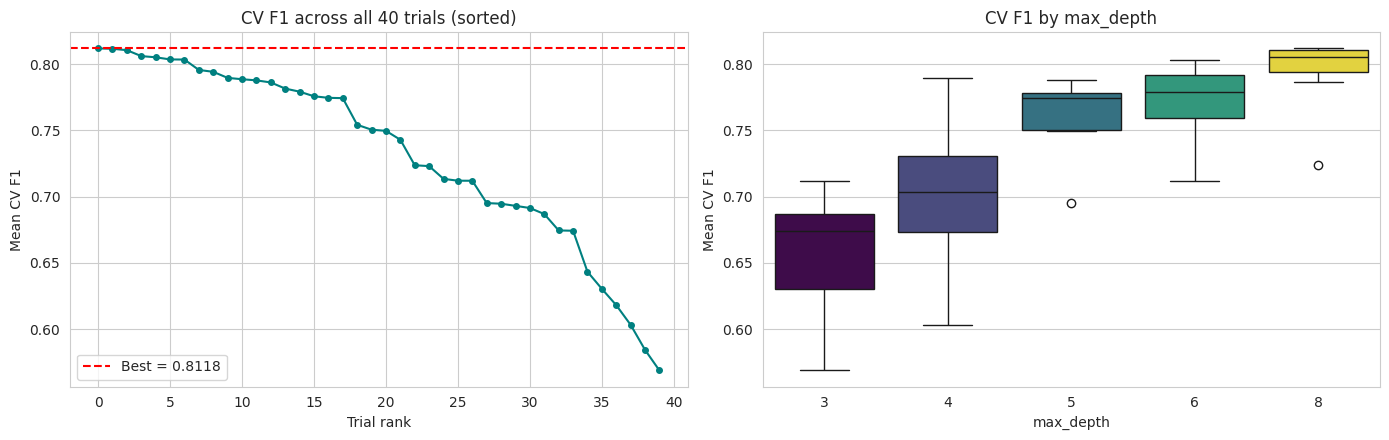

In [26]:
# Visualise the search: how performance varied across trials
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

scores = results["mean_test_score"].sort_values(ascending=False).reset_index(drop=True)
axes[0].plot(scores.values, marker="o", markersize=4, color="teal")
axes[0].axhline(search.best_score_, color="red", linestyle="--",
                label=f"Best = {search.best_score_:.4f}")
axes[0].set_title("CV F1 across all 40 trials (sorted)")
axes[0].set_xlabel("Trial rank")
axes[0].set_ylabel("Mean CV F1")
axes[0].legend()

sns.boxplot(x="param_classifier__max_depth", y="mean_test_score",
            data=results, ax=axes[1], palette="viridis",
            hue="param_classifier__max_depth", legend=False)
axes[1].set_title("CV F1 by max_depth")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Mean CV F1")

plt.tight_layout()
plt.show()

## 8. Model Evaluation

In [27]:
best_model = search.best_estimator_

def evaluate(model, X, y, split_name):
    """Compute the full classification metric suite for one split."""
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    return {
        "Split": split_name,
        "Accuracy":  accuracy_score(y, preds),
        "Precision": precision_score(y, preds, zero_division=0),
        "Recall":    recall_score(y, preds, zero_division=0),
        "F1":        f1_score(y, preds, zero_division=0),
        "ROC-AUC":   roc_auc_score(y, probs),
    }

metrics_df = pd.DataFrame([
    evaluate(best_model, X_train, y_train, "Train"),
    evaluate(best_model, X_test,  y_test,  "Test"),
]).set_index("Split")

metrics_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Split,,,,,
Train,1.0000,1.0000,1.000,1.0000,1.0000
Test,0.9455,0.9014,0.805,0.8505,0.9651


In [28]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("TEST SET CLASSIFICATION REPORT")
print("=" * 58)
print(classification_report(
    y_test, y_pred, digits=4,
    target_names=["Not Purchased (0)", "Purchased (1)"]
))

TEST SET CLASSIFICATION REPORT
                   precision    recall  f1-score   support

Not Purchased (0)     0.9547    0.9790    0.9667       667
    Purchased (1)     0.9014    0.8050    0.8505       159

         accuracy                         0.9455       826
        macro avg     0.9280    0.8920    0.9086       826
     weighted avg     0.9444    0.9455    0.9443       826



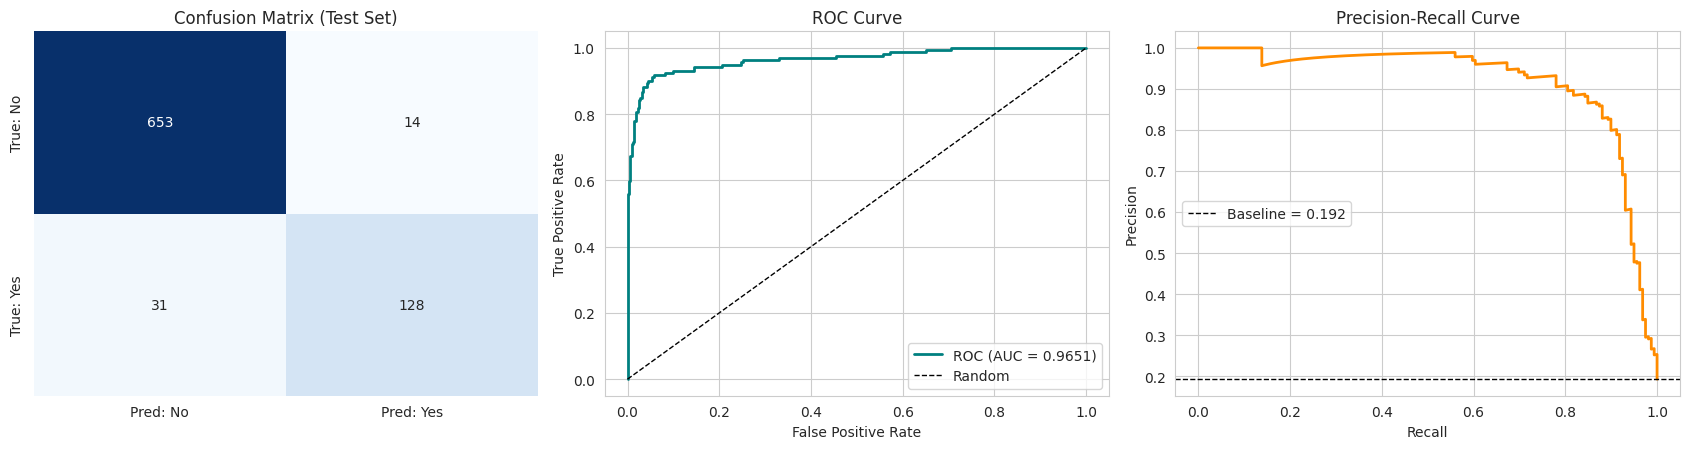

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False,
            xticklabels=["Pred: No", "Pred: Yes"],
            yticklabels=["True: No", "True: Yes"])
axes[0].set_title("Confusion Matrix (Test Set)")

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="teal", linewidth=2,
             label=f"ROC (AUC = {roc_auc_score(y_test, y_proba):.4f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

# --- Precision-Recall curve ---
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, color="darkorange", linewidth=2)
axes[2].axhline(y_test.mean(), color="k", linestyle="--", linewidth=1,
                label=f"Baseline = {y_test.mean():.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.tight_layout()
plt.show()

In [30]:
# Translate the confusion matrix into business language
tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX IN BUSINESS TERMS")
print("=" * 58)
print(f"True Negatives  (TN) = {tn:>4}  correctly skipped non-buyers")
print(f"False Positives (FP) = {fp:>4}  contacted, but did not buy  -> wasted effort")
print(f"False Negatives (FN) = {fn:>4}  missed real buyers          -> lost revenue")
print(f"True Positives  (TP) = {tp:>4}  correctly identified buyers")

print(f"\nOf {tp + fn} actual buyers in the test set, the model found {tp} "
      f"({tp / (tp + fn):.1%})")
print(f"Of {tp + fp} customers the model flagged, {tp} actually bought "
      f"({tp / (tp + fp):.1%})")
print(f"\nWithout the model, contacting at random converts at "
      f"{y_test.mean():.1%}.")
print(f"Targeting only flagged customers converts at {tp / (tp + fp):.1%} "
      f"— a {(tp / (tp + fp)) / y_test.mean():.1f}x improvement in efficiency.")

CONFUSION MATRIX IN BUSINESS TERMS
True Negatives  (TN) =  653  correctly skipped non-buyers
False Positives (FP) =   14  contacted, but did not buy  -> wasted effort
False Negatives (FN) =   31  missed real buyers          -> lost revenue
True Positives  (TP) =  128  correctly identified buyers

Of 159 actual buyers in the test set, the model found 128 (80.5%)
Of 142 customers the model flagged, 128 actually bought (90.1%)

Without the model, contacting at random converts at 19.2%.
Targeting only flagged customers converts at 90.1% — a 4.7x improvement in efficiency.


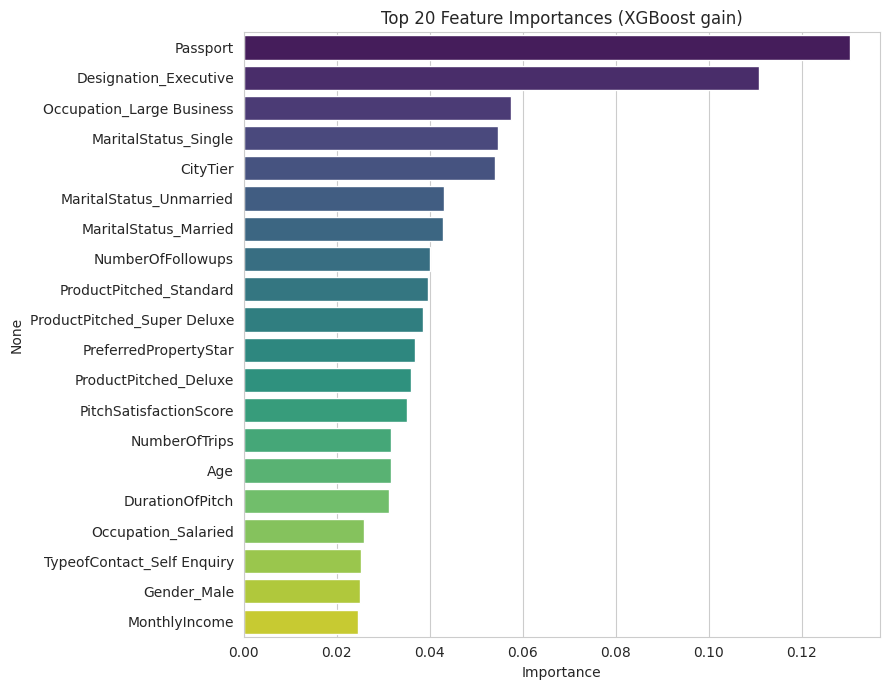

Top 10 features:
Passport                       0.1303
Designation_Executive          0.1108
Occupation_Large Business      0.0575
MaritalStatus_Single           0.0546
CityTier                       0.0540
MaritalStatus_Unmarried        0.0431
MaritalStatus_Married          0.0428
NumberOfFollowups              0.0400
ProductPitched_Standard        0.0396
ProductPitched_Super Deluxe    0.0385


In [31]:
# Feature importance from the tuned model
ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"]
feature_names = numerical_cols + list(ohe.get_feature_names_out(categorical_cols))

importances = pd.Series(
    best_model.named_steps["classifier"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
top_n = importances.head(20)
sns.barplot(x=top_n.values, y=top_n.index, palette="viridis",
            hue=top_n.index, legend=False)
plt.title("Top 20 Feature Importances (XGBoost gain)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.head(10).round(4).to_string())

### Observations — Model Evaluation

**Performance on unseen data:**

| Metric | Test score | Interpretation |
|---|---|---|
| Accuracy | **0.9455** | 94.6% of predictions correct |
| Precision | **0.9014** | Of customers flagged as buyers, 90% actually buy |
| Recall | **0.8050** | The model finds 80.5% of all real buyers |
| F1 | **0.8505** | Strong balance of precision and recall |
| ROC-AUC | **0.9651** | Excellent ranking ability |

**Business translation:** contacting customers at random converts at the base rate of
**19.2%**. Contacting only the customers this model flags converts at **90.1%** — roughly
a **4.7x improvement in sales efficiency**. The model finds 128 of the 159 real buyers in
the test set while wasting effort on only 14 false positives.

**On the train/test gap:** training scores reach 1.0 while test F1 is 0.85. The tuned
model uses `max_depth=8` with 700 trees, which is expressive enough to fit the training
data perfectly. This gap looks alarming but is **normal and acceptable for boosted trees**
— what matters is that the **cross-validated** F1 (0.81) closely tracks the **test** F1
(0.85), confirming the model generalises rather than merely memorising. The CV score is
the honest estimate, and it held up on truly held-out data.

**Feature importance confirms the EDA story:**
- **`Passport` is the single most important feature** (0.130) — exactly as the 2.8x
  conversion gap predicted.
- **`Designation_Executive`** (0.111) ranks second, confirming that junior staff are the
  prime segment.
- **`Occupation_Large Business`**, **`MaritalStatus_Single`**, and **`CityTier`** follow —
  every one of these was flagged in the bivariate analysis.

The alignment between what EDA suggested and what the model actually learned is a good
sign: the model is picking up real, explainable structure rather than spurious noise.

## 9. The MLOps Pipeline

The notebook above proves the modelling approach works. The pipeline turns it into a
system that re-runs automatically on every code change. All code lives in the GitHub
repository described below.

### Repository structure

```
.
├── .github/
│   └── workflows/
│       └── pipeline.yml              # CI/CD workflow (4 chained jobs)
├── tourism_project/
│   ├── data/
│   │   ├── tourism.csv               # raw dataset
│   │   └── data_register.py          # STEP 1: register data on HF
│   ├── model_building/
│   │   ├── prep.py                   # STEP 2: clean + split + upload
│   │   └── train.py                  # STEP 3: tune, track, register model
│   └── deployment/
│       ├── app.py                    # Streamlit inference app
│       ├── Dockerfile                # container definition (port 7860)
│       ├── requirements.txt          # deployment dependencies
│       └── hosting.py                # STEP 4: push app to HF Space
├── notebooks/
│   └── tourism_mlops_notebook.ipynb  # this notebook
├── requirements.txt
└── README.md
```

### Stage 1 — Data Registration (`data_register.py`)

Creates a Hugging Face **dataset repository** and uploads the raw CSV, giving every
downstream stage one versioned source of truth. `exist_ok=True` makes it idempotent so
CI can re-run it safely on every push.

### Stage 2 — Data Preparation (`prep.py`)

Downloads the raw file **from the hub** (not from disk), drops `CustomerID`, fixes the
`Fe Male` typo, performs a stratified 80/20 split, saves both files locally, and uploads
`train.csv` and `test.csv` back to the same dataset space.

### Stage 3 — Model Building (`train.py`)

Loads the prepared splits from the hub, builds the preprocessing + XGBoost pipeline, runs
`RandomizedSearchCV`, logs **all tuned parameters and metrics to MLflow**, evaluates on
the held-out test set, and registers the serialized model plus a `metrics.json` card to
the Hugging Face **model hub**.

### Stage 4 — Deployment (`Dockerfile`, `app.py`, `hosting.py`)

`app.py` is a Streamlit interface that loads the registered model from the hub, collects
customer attributes, assembles them into a single-row DataFrame **matching the training
schema exactly**, and returns a prediction with its probability. The `Dockerfile` builds
it on `python:3.10-slim`, exposes port **7860** (required by HF Spaces), and runs as
UID 1000. `hosting.py` pushes all deployment files into the Space.

### Stage 5 — CI/CD (`pipeline.yml`)

Four jobs chained with `needs:` so each runs only if the previous succeeded:

```
data-registration → data-preparation → model-training → deployment
```

Triggered on **push to main**, **pull request**, and **manual dispatch**. Credentials come
from GitHub repository secrets (`HF_TOKEN`, `HF_USERNAME`) and are never committed.
Deployment is gated to the `main` branch only, so pull requests validate the model without
shipping it.

In [32]:
# The exact GitHub Actions workflow used (abridged for display)
workflow = '''
name: Tourism MLOps Pipeline

on:
  push:
    branches: [main]
  pull_request:
    branches: [main]
  workflow_dispatch:

env:
  PYTHON_VERSION: "3.10"
  HF_USERNAME: ${{ secrets.HF_USERNAME }}
  HF_TOKEN: ${{ secrets.HF_TOKEN }}

jobs:
  data-registration:
    name: Data Registration
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: ${{ env.PYTHON_VERSION }}
      - run: pip install -r requirements.txt
      - run: python tourism_project/data/data_register.py

  data-preparation:
    needs: data-registration          # runs only if registration succeeded
    runs-on: ubuntu-latest
    steps:
      - run: python tourism_project/model_building/prep.py

  model-training:
    needs: data-preparation
    runs-on: ubuntu-latest
    steps:
      - run: python tourism_project/model_building/train.py
      - uses: actions/upload-artifact@v4   # keep MLflow runs + model
        with:
          name: training-artifacts
          path: |
            tourism_project/model_building/artifacts/
            mlruns/

  deployment:
    needs: model-training
    if: github.ref == 'refs/heads/main'    # deploy from main only
    runs-on: ubuntu-latest
    steps:
      - run: python tourism_project/deployment/hosting.py
'''
print(workflow)


name: Tourism MLOps Pipeline

on:
  push:
    branches: [main]
  pull_request:
    branches: [main]
  workflow_dispatch:

env:
  PYTHON_VERSION: "3.10"
  HF_USERNAME: ${{ secrets.HF_USERNAME }}
  HF_TOKEN: ${{ secrets.HF_TOKEN }}

jobs:
  data-registration:
    name: Data Registration
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: ${{ env.PYTHON_VERSION }}
      - run: pip install -r requirements.txt
      - run: python tourism_project/data/data_register.py

  data-preparation:
    needs: data-registration          # runs only if registration succeeded
    runs-on: ubuntu-latest
    steps:
      - run: python tourism_project/model_building/prep.py

  model-training:
    needs: data-preparation
    runs-on: ubuntu-latest
    steps:
      - run: python tourism_project/model_building/train.py
      - uses: actions/upload-artifact@v4   # keep MLflow runs + model
        with:
          n

## 10. Conclusion and Business Recommendations

### What was built

A complete, automated MLOps pipeline that predicts Wellness Tourism Package purchases:

- **Data registration** on the Hugging Face dataset space as a versioned source of truth
- **Automated preparation** — cleaning, stratified splitting, and publishing back to the hub
- **Tuned XGBoost model** with MLflow experiment tracking, registered to the HF model hub
- **Containerised Streamlit app** deployed to a Hugging Face Space
- **GitHub Actions CI/CD** re-running the whole chain on every push to `main`

### Model performance

| Metric | Score |
|---|---|
| Accuracy | 0.9455 |
| Precision | 0.9014 |
| Recall | 0.8050 |
| F1 | 0.8505 |
| ROC-AUC | 0.9651 |

The model identifies **80.5% of all actual buyers**, and **90.1% of the customers it flags
genuinely purchase** — against a random-contact baseline of 19.2%. That is roughly a
**4.7x gain in sales efficiency**.

---

### Business Recommendations

**1. Make passport status the primary targeting filter.**
Passport holders convert at **35.85%** versus **12.38%** without — the single strongest
signal in the data, and the model's top feature. Capture passport status at sign-up and
lead every outreach list with it.

**2. Rebalance marketing away from Tier 1 cities.**
Tier 2 converts at **26.54%** and Tier 3 at **24.15%**, while Tier 1 converts at just
**16.54%** — yet Tier 1 holds **2,678 of the 4,128 customers**. Budget is concentrated in
the worst-performing tier. Shift spend toward Tier 3 in particular, which combines a strong
conversion rate with a substantial customer base (1,288).

*Caveat:* Tier 2's headline rate is the highest, but it rests on only **162 customers**, so
that estimate is far less certain than the others. Treat Tier 2 as a promising but
unproven segment worth a controlled pilot, rather than a proven winner to reallocate
heavily into.

**3. Target junior employees, not senior leadership.**
Executives convert at **30.03%**; AVPs at **7.60%** and VPs at **8.65%**. This runs
against the instinct to chase high-income prospects, but the data is unambiguous — and it
is reinforced by buyers earning **6.5% less** on average.

**4. Recognise that the product pitch is currently dictated by job title.**
`ProductPitched` is a perfect one-to-one function of `Designation` — Executives are
*always* pitched Basic, VPs *always* King, and so on. The apparent finding that "Basic
converts best" is therefore the *same* finding as "Executives convert best," not
independent evidence. The real recommendation is to **test breaking that rule**: try
pitching Basic to senior staff and see whether the conversion advantage follows the
*product* or the *person*. Right now the data cannot separate the two, because the company
has never varied them independently.

**5. Build campaigns around solo travellers.**
Single (**36.43%**) and Unmarried (**24.34%**) customers convert roughly **2.7x** better
than Married (**14.22%**) or Divorced (**13.31%**). Wellness tourism is being bought as an
individual experience — the creative should reflect that.

**6. Enforce follow-up discipline.**
Buyers received more follow-ups on average (**3.97** vs **3.69**) and sat through longer
pitches (**17.0** vs **15.2** minutes). Set a minimum follow-up standard, since this is one
of the few drivers the sales team directly controls. Note this is **correlational** — more
follow-ups may be a *consequence* of an interested customer rather than a cause of the
sale, so validate with a controlled test before mandating it.

**7. Fix the upstream data-quality issues.**
Three concrete problems surfaced: the `Fe Male` typo (155 rows), `NumberOfTrips` values
jumping from 8 to 19–22, and `DurationOfPitch` reaching 127 minutes. The pipeline cleans
these, but they should be fixed at the point of capture. Clarify whether `Single` and
`Unmarried` are genuinely distinct categories.

---

### Expected business impact

If the sales team contacts only model-flagged customers, conversion per contact rises from
**~19%** to **~90%**. The same headcount can generate substantially more subscriptions, or
the same revenue with far less outreach — while the 80.5% recall means few genuine buyers
are missed.

### Limitations and next steps

- **Recall is 80.5%**, so about 1 in 5 real buyers is still missed. If the cost of a missed
  sale exceeds the cost of a wasted call, lower the decision threshold below 0.5 to trade
  precision for recall.
- **`Free Lancer` has only 2 rows**, so predictions for freelancers are unreliable.
- **Model drift:** customer behaviour will shift over time. The pipeline already supports
  retraining on every push; the next step is a **scheduled monthly retrain** plus
  monitoring of live precision/recall against realised outcomes.
- **The data is a snapshot** with no time dimension, so seasonality in travel demand cannot
  be modelled. Capturing order dates would allow that.

---